# Bias Analysis - Credit Application Dataset

## Introduction

This notebook investigates potential bias in NovaCred’s historical credit decisions. 
The objective is to evaluate whether demographic attributes such as **gender** or **age** influence loan approval outcomes.

We begin by preparing the dataset and ensuring that relevant attributes are standardized. 
In particular, gender labels must be consistent and the applicant’s **age is derived from the date of birth field**.

Once the dataset is prepared, we conduct several fairness analyses:

1. **Disparate Impact Analysis (Gender)** – evaluating whether approval rates differ significantly between male and female applicants using the four-fifths rule.
2. **Age-Based Bias Analysis** – examining approval patterns across age groups.
3. **Proxy Discrimination Analysis** – investigating whether variables such as ZIP code indirectly capture protected characteristics.
4. **Interaction Effects** – exploring whether combinations of attributes (e.g., age and gender) produce systematic differences in approval outcomes.

These analyses aim to identify potential algorithmic bias in the lending process and assess whether the system may produce discriminatory outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_bias = pd.read_json("../data/processed/cleaned_credit_applications.json", orient="records")


----
## Data Preparation and Validation for Bias Analysis

Before performing fairness analysis, we verify that key attributes used in the
analysis are correctly formatted and contain expected values.

The following checks are performed:

- Validate that the **gender column contains only expected categories**
- Convert **date of birth to datetime format** and derive the applicant's age

These validation steps ensure that the fairness analysis is based on
well-defined and reliable variables.


In [3]:
# Create working dataset

print("===== BIAS ANALYSIS DATA CHECKS =====\n")

# 1. Gender validation
print("Gender value counts:")
print(df_bias['applicant_info.gender'].value_counts(dropna=False))

print("\nUnique gender values:")
print(df_bias['applicant_info.gender'].unique())


# 2. Date of birth format
print("\nChecking DOB format...")

df_bias['applicant_info.date_of_birth'] = pd.to_datetime(
    df_bias['applicant_info.date_of_birth'], errors='coerce'
)

invalid_dob = df_bias['applicant_info.date_of_birth'].isna().sum()

print("Invalid DOB values:", invalid_dob)


# 3. Age calculation check
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

print("\nAge summary:")
print(df_bias['age'].describe())


# 4. Approval variable
print("\nLoan approval distribution:")
print(df_bias['decision.loan_approved'].value_counts())


# 5. Missing values in key fields
print("\nMissing values in key analysis columns:")

cols_to_check = [
    'applicant_info.gender',
    'applicant_info.date_of_birth',
    'decision.loan_approved'
]

print(df_bias[cols_to_check].isnull().sum())

===== BIAS ANALYSIS DATA CHECKS =====

Gender value counts:
applicant_info.gender
Female    251
Male      247
            2
Name: count, dtype: int64

Unique gender values:
['Male' 'Female' '']

Checking DOB format...
Invalid DOB values: 4

Age summary:
count    496.000000
mean      40.768145
std       10.962409
min       23.000000
25%       32.000000
50%       39.000000
75%       47.000000
max       67.000000
Name: age, dtype: float64

Loan approval distribution:
decision.loan_approved
True     292
False    208
Name: count, dtype: int64

Missing values in key analysis columns:
applicant_info.gender           0
applicant_info.date_of_birth    4
decision.loan_approved          0
dtype: int64


The diagnostic checks reveal two minor data issues that must be addressed before conducting fairness analysis.

First, two records contain empty values in the gender field. Since disparate impact analysis requires clearly defined demographic groups, these records cannot be reliably assigned to either group and will be excluded from the gender fairness analysis.
Second, four records contain invalid or missing birthdates, which prevents age calculation. These records will be excluded from analyses involving age.

In [4]:
# --- Fix gender issue ---
df_bias['applicant_info.gender'] = df_bias['applicant_info.gender'].replace('', 'Unknown')

# Remove records with unknown gender for fairness analysis
df_bias = df_bias[df_bias['applicant_info.gender'].isin(['Male', 'Female'])]

# --- Remove rows with invalid DOB (needed for age analysis) ---
df_bias = df_bias[df_bias['applicant_info.date_of_birth'].notna()]

# Recalculate age to ensure consistency
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

# Create approval indicator
df_bias['approved'] = df_bias['decision.loan_approved']

# Final dataset check
print("Final dataset size:", len(df_bias))
print(df_bias['applicant_info.gender'].value_counts())

Final dataset size: 495
applicant_info.gender
Female    249
Male      246
Name: count, dtype: int64


------


## Gender Disparate Impact Analysis

To evaluate potential bias in loan approval decisions, we compute the **Disparate Impact (DI) ratio** for gender.

Disparate Impact compares the approval rate of a potentially disadvantaged group (unprivileged group) to the approval rate of a reference group (privileged group). A DI ratio below **0.8** may indicate potential discriminatory impact.

In [5]:
# Approval rate by gender
approval_rates = df_bias.groupby('applicant_info.gender')['decision.loan_approved'].mean()

print("Approval rate by gender:")
print(approval_rates)

Approval rate by gender:
applicant_info.gender
Female    0.506024
Male      0.658537
Name: decision.loan_approved, dtype: float64


The results show that male applicants have a higher approval rate than female applicants. Therefore, male applicants are treated as the **privileged group**, while female applicants represent the **unprivileged group** for the purpose of the disparate impact analysis.

The next step is to compute the Disparate Impact ratio.

Female approval rate: 0.5060240963855421
Male approval rate: 0.6585365853658537

Disparate Impact Ratio: 0.7684069611780454


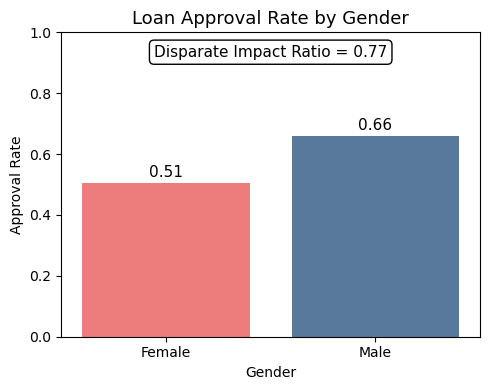

In [6]:
# Extract approval rates
female_rate = approval_rates['Female']
male_rate = approval_rates['Male']

# Compute Disparate Impact
di_ratio = female_rate / male_rate

print("Female approval rate:", female_rate)
print("Male approval rate:", male_rate)
print("\nDisparate Impact Ratio:", di_ratio)

# Plotting graph
plt.figure(figsize=(5,4))

sns.barplot(
    x=approval_rates.index,
    y=approval_rates.values,
    palette=["#FF6B6B", "#4E79A7"]
)

plt.title("Loan Approval Rate by Gender", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add approval rate labels
for i, v in enumerate(approval_rates.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

# Add DI ratio annotation
plt.text(
    0.5, 0.92,
    f"Disparate Impact Ratio = {di_ratio:.2f}",
    ha='center',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.show()

The computed Disparate Impact ratio is approximately **0.77**, which is below
the commonly used **0.8 threshold**. This suggests that the **credit decision algorithm may be producing different approval outcomes across gender groups**.

In [7]:
from scipy.stats import chi2_contingency

# Create contingency table
gender_table = pd.crosstab(
    df_bias['applicant_info.gender'],
    df_bias['decision.loan_approved']
)

print("Contingency table:")
print(gender_table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(gender_table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)

Contingency table:
decision.loan_approved  False  True 
applicant_info.gender               
Female                    123    126
Male                       84    162

Chi-square statistic: 11.211547625416834
p-value: 0.0008128989785515727


A Chi-square test of independence was conducted to evaluate whether loan approval outcomes are independent of gender.

The test produced a **p-value of approximately 0.0008**, which is well below the commonly used significance threshold of 0.05. This indicates that the observed difference in approval rates between male and female applicants is **statistically significant**.

Combined with the previously computed Disparate Impact ratio, this result suggests that the credit decision algorithm produces approval outcomes that differ across gender groups and warrants further investigation into the features influencing the model's decisions.

-----
## Age-Based Bias Analysis

In addition to gender, we analyze whether loan approval outcomes vary
across different age groups.

Age is derived from the applicant's date of birth and applicants are
grouped into age ranges to compare approval rates across groups. This
helps identify whether the model produces systematically different
approval outcomes for younger or older applicants.

age_group
18–25    0.454545
26–35    0.464968
36–50    0.680000
51–65    0.578313
65+      0.500000
Name: decision.loan_approved, dtype: float64


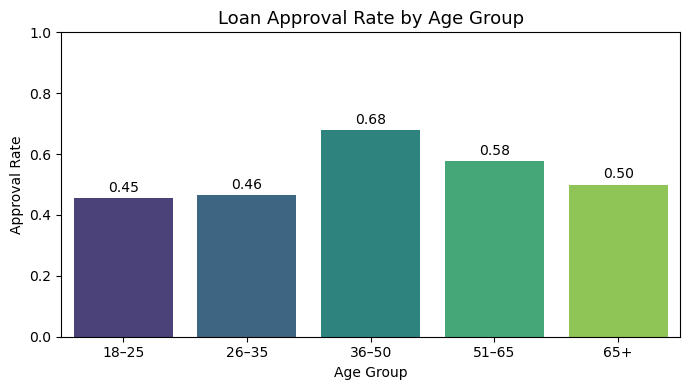

In [8]:
# Create age groups
bins = [18, 25, 35, 50, 65, 100]
labels = ['18–25', '26–35', '36–50', '51–65', '65+']

df_bias['age_group'] = pd.cut(df_bias['age'], bins=bins, labels=labels)

# Approval rate by age group
age_approval_rates = df_bias.groupby('age_group')['decision.loan_approved'].mean()

print(age_approval_rates)

# Plotting graph
plt.figure(figsize=(7,4))

sns.barplot(
    x=age_approval_rates.index,
    y=age_approval_rates.values,
    palette="viridis"
)

plt.title("Loan Approval Rate by Age Group", fontsize=13)
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add labels
for i, v in enumerate(age_approval_rates.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

The visualization shows variation in approval rates across age groups.
Applicants aged **36–50** exhibit the highest approval rate, while
younger applicants (18–35) have lower approval rates.

These differences may reflect how the credit decision algorithm weighs
financial attributes correlated with age, such as income levels,
employment stability, or credit history length.

In [9]:
# Create contingency table
age_table = pd.crosstab(
    df_bias['age_group'],
    df_bias['decision.loan_approved']
)

print("Contingency table:")
print(age_table)

# Chi-square test
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print("\nChi-square statistic:", chi2_age)
print("p-value:", p_age)

Contingency table:
decision.loan_approved  False  True 
age_group                           
18–25                      12     10
26–35                      84     73
36–50                      72    153
51–65                      35     48
65+                         4      4

Chi-square statistic: 19.413962899507197
p-value: 0.0006515962416621619


-----
## Proxy Discrimination Analysis

In addition to direct demographic attributes such as gender or age, models may produce biased outcomes through **proxy
variables**. These are non-demographic features that correlate with
demographic characteristics and indirectly influence model decisions.

A common proxy variable in credit systems is **ZIP code**, since
geographic location often correlates with socioeconomic factors.

In this section, we examine whether loan approval rates vary across ZIP
codes and assess whether geographic attributes could indirectly influence
the model’s approval decisions.

In [14]:
zip_counts = df_bias['applicant_info.zip_code'].value_counts()

print("Applications per ZIP code:")
print(zip_counts.head(10))

Applications per ZIP code:
applicant_info.zip_code
10048    8
10096    7
90284    7
10004    6
10019    6
10020    6
10057    6
90237    5
10012    5
10070    5
Name: count, dtype: int64


In [15]:
valid_zips = zip_counts[zip_counts >= 5].index

df_zip_filtered = df_bias[
    df_bias['applicant_info.zip_code'].isin(valid_zips)
]

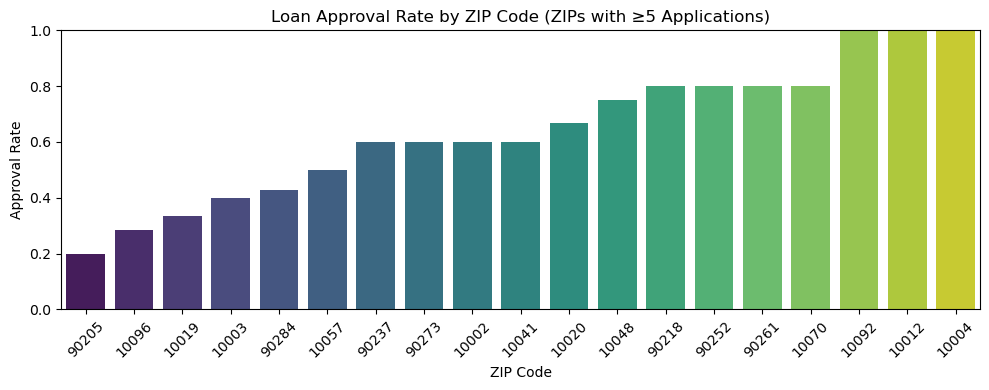

In [18]:
zip_approval = df_zip_filtered.groupby(
    'applicant_info.zip_code'
)['decision.loan_approved'].mean()

zip_approval = zip_approval.sort_values()


plt.figure(figsize=(10,4))

sns.barplot(
    x=zip_approval.index.astype(str),
    y=zip_approval.values,
    palette="viridis"
)

plt.title("Loan Approval Rate by ZIP Code (ZIPs with ≥5 Applications)")
plt.xlabel("ZIP Code")
plt.ylabel("Approval Rate")

plt.ylim(0,1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()